# Visualização: gráfico de dispersão

Carrega o dataset já transformado gerado no `02_transformacao.ipynb` e plota o gráfico de dispersão com as faixas de IMC.

O gráfico abaixo desenha, para cada altura, os limites de peso que separam as classificações de IMC (Abaixo do peso, Peso normal, Sobrepeso, Obesidade Grau I e Obesidade Grau II)

In [52]:
import numpy as np 
import pandas as pd
import duckdb
import matplotlib.pyplot as pyplot

In [ ]:
df = pd.read_csv(r"../data/data_frame_transformado.csv")

     Sexo  Altura    Peso
0       M    1.87  109.72
1       M    1.74   73.62
2       M    1.88   96.49
3       M    1.82   99.81
4       M    1.77   93.60
...   ...     ...     ...
9995    F    1.68   62.04
9996    F    1.70   77.50
9997    F    1.62   58.27
9998    F    1.75   74.32
9999    F    1.57   51.55

[10000 rows x 3 columns]


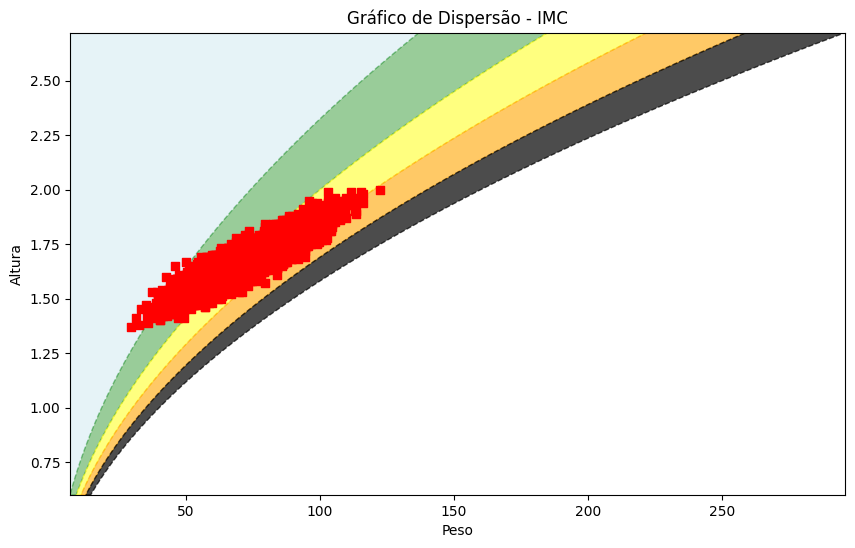

In [72]:

pyplot.figure(figsize=(10,6))
pyplot.title("Gráfico de Dispersão - IMC")
pyplot.xlabel("Peso")
pyplot.ylabel("Altura")

alturas = np.linspace(0.60, 2.72, 1000)

baixo_peso  = 18.5 * (alturas ** 2)
peso_normal = 25 * (alturas ** 2)
sobrepeso   = 30 * (alturas ** 2)
obesidade_1 = 35 * (alturas ** 2)
obesidade_2 = 40 * (alturas ** 2)

pyplot.fill_betweenx(alturas, 0, baixo_peso, color="lightblue", alpha=0.3, label="Abaixo do Peso", linestyle="--")
pyplot.fill_betweenx(alturas, baixo_peso, peso_normal, color="green", alpha=0.4, label="Peso Normal",  linestyle="--")
pyplot.fill_betweenx(alturas, peso_normal, sobrepeso, color="yellow", alpha=0.5, label="Sobrepeso",  linestyle="--")
pyplot.fill_betweenx(alturas, sobrepeso, obesidade_1, color="orange", alpha=0.6, label="Obesidade Grau I",  linestyle="--")
pyplot.fill_betweenx(alturas, obesidade_1, obesidade_2, color="black", alpha=0.7, label="Obesidade Grau II", linestyle="--")

pyplot.ylim(min(alturas), max(alturas))
pyplot.xlim(min(baixo_peso), max(obesidade_2))

pyplot.scatter(df['Peso'], df['Altura'], marker="s", color="red")

pyplot.show()

## Segmentação por Sexo

O mesmo gráfico de dispersão acima, agora separando os pontos por sexo (verde para homens, rosa para mulheres). O objetivo é comparar visualmente se um dos grupos se concentra mais em alguma faixa de IMC específica.

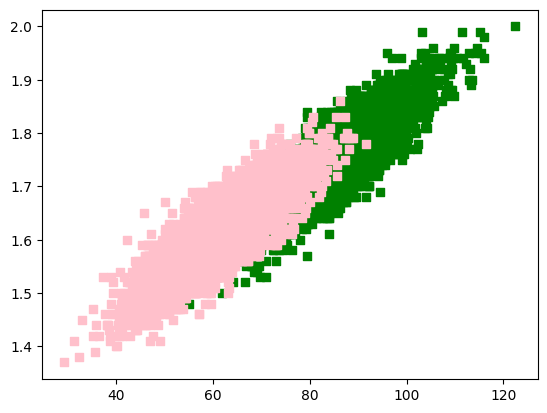

In [73]:
homens = df[df['Sexo'] == 'M']
mulheres = df[df['Sexo'] == 'F']

pyplot.scatter(homens['Peso'], homens['Altura'], marker="s", color="green")
pyplot.scatter(mulheres['Peso'], mulheres['Altura'], marker="s", color="pink")

### Análise de IMC e Considerações Finais

A percepção visual do gráfico de dispersão é confirmada aqui com números exatos,
usando SQL

In [74]:
duckdb.sql("""
    WITH imc_calculado AS (
        SELECT
            Sexo,
            Peso / (Altura * Altura) AS IMC
        FROM '../data/data_frame_transformado.csv'
    ),
    classificado AS (
        SELECT
            Sexo,
            CASE
                WHEN IMC < 18.5 THEN 'Abaixo do peso'
                WHEN IMC < 25 THEN 'Peso normal'
                WHEN IMC < 30 THEN 'Sobrepeso'
                WHEN IMC < 35 THEN 'Obesidade Grau I'
                WHEN IMC < 40 THEN 'Obesidade Grau II'
                ELSE 'Obesidade Grau III'
            END AS Classe
        FROM imc_calculado
    )
    SELECT
        Sexo,
        Classe,
        COUNT(*) AS Quantidade,
        COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (PARTITION BY Sexo) AS Percentual
    FROM classificado
    GROUP BY Sexo, Classe
""").show()


┌─────────┬──────────────────┬────────────┬────────────┐
│  Sexo   │      Classe      │ Quantidade │ Percentual │
│ varchar │     varchar      │   int64    │   double   │
├─────────┼──────────────────┼────────────┼────────────┤
│ F       │ Peso normal      │       3779 │      75.58 │
│ F       │ Sobrepeso        │       1185 │       23.7 │
│ F       │ Abaixo do peso   │         36 │       0.72 │
│ M       │ Peso normal      │        199 │       3.98 │
│ M       │ Sobrepeso        │       4493 │      89.86 │
│ M       │ Obesidade Grau I │        308 │       6.16 │
└─────────┴──────────────────┴────────────┴────────────┘



## Considerações Finais

Os números confirmam o que o gráfico de dispersão já sugeria visualmente: existe uma diferença expressiva entre os sexos.

- **Homens**: praticamente 90% estão em sobrepeso, e uma parcela adicional (6%) já está em Obesidade Grau I. Pouquíssimos homens (4%) mantêm peso normal. Por outro lado, ninguém no dataset chega a Obesidade Grau II, o que é um ponto positivo dentro desse cenário.
- **Mulheres**: o quadro é bem diferente, com a maioria (75%) em peso normal e apenas 23,7% em sobrepeso. Nenhuma mulher entra em nenhum grau de obesidade.

Isso mostra que, nesse dataset, as mulheres apresentam um indicador de IMC bem mais saudável que os homens, que se concentram fortemente na faixa de sobrepeso. O motivo por trás dessa diferença não é possível determinar apenas com essas colunas, seria necessário investigar outras variáveis Em relação a segmentação por sexo, ajudou muito a enxergar essa diferença: olhando o dataset como um todo, a distribuição ficaria misturada e essa disparidade entre os grupos não ficaria evidente.